# Imports

In [2]:
from utils.imports import *
# 1. Define the path to your extracted ffmpeg bin folder
# (Change this to wherever you actually saved it)
ffmpeg_bin_path = r"C:\Users\cgheorgh\ffmpeg\ffmpeg-8.1.1-full_build-shared\bin"
# 2. Add it to the Windows PATH for this specific Python session
os.environ["PATH"] += os.pathsep + ffmpeg_bin_path
# 3. Tell Python where to look for DLLs (Required for Python 3.8+ on Windows)
if hasattr(os, 'add_dll_directory'):
    os.add_dll_directory(ffmpeg_bin_path)


dataset_roots:dict = [r'utils\assignment_2_dataset\train',
                      r'utils\assignment_2_dataset\validation',
                      r'utils\assignment_2_dataset\test']

### 2.3.c)

[(0, 50), (-100, 50), (0, 150), (100, 150)]


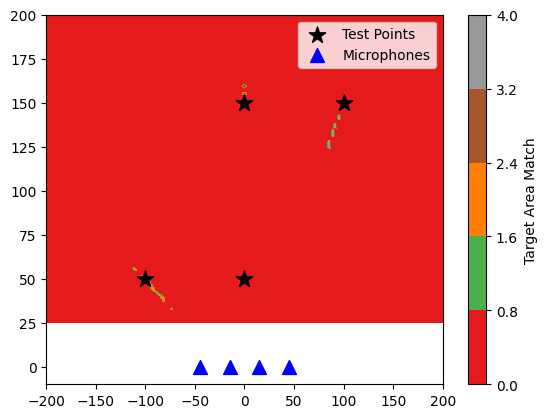

In [152]:
# 1. Baseline initialization enforcing x,y global bounds (-200, 200);(-25,200) and some other variables (e.g., source path)
input:str = r'utils\assignment_2_dataset\train\bird1.mp3'
waveform, sample_rate = torchaudio.load(input)
# 1.2. Averaging out the signal's channels 
mono_waveform = torch.mean(waveform, dim=0) # Apply transformation
mic_locs:list=[(-45, 0), (-15,0), (15, 0),(45,0)]
fixed_locations:list = [(0, 50), (-100, 50), (0, 150), (100, 150)] # List of fixed locations
lb_x, up_x = -200, 200
lb_y, up_y = 25, 200
fixed_locations_time_delays:list=[]
# # 2. Parsing the list holding fixed coordinates and saving their time delays integers;
# # ... Only one song was retained for the sake of simplicity
# 2.1 Building the 2D space
x = np.linspace(lb_x, up_x, 200)
y = np.linspace(lb_y, up_y, 200)
xv, yv = np.meshgrid(x, y) # Return a tuple (`xv` and `yv`) of coordinates matrices from coordinates vectors
z = np.zeros_like(xv) # Create in advance the required z whose dimension matches the 2D tuple of coordinates; could be either of the two xv and yv

# # 3. Parsing over the space coordinates and compare against delays calculated based on fix locations
for loc in fixed_locations:
    _, delays = audio_simulator(mono_waveform, loc, mic_locs)
    # 3.1 Calculate difference relative to the first microphone
    relative_sig = [delays[1]-delays[0], delays[2]-delays[0], delays[3]-delays[0]]
    fixed_locations_time_delays.append(relative_sig)

for i in range(xv.shape[0]):
    for j in range(xv.shape[1]):
        
        pixel_x = xv[i, j]
        pixel_y = yv[i, j]
        
        # Run your simulator for this one pixel to get its 4-mic delay list
        _, delays = audio_simulator(mono_waveform, (pixel_x, pixel_y), mic_locs)
        
        # 5. Check if this pixel perfectly matches any of our 4 target signatures
        # 5.1 Calculate pixel difference relative to the first microphone
        pixel_relative_sig = [delays[1]-delays[0], delays[2]-delays[0], delays[3]-delays[0]]
        # 5.2  compare the relative signatures!
        if pixel_relative_sig == fixed_locations_time_delays[0]:
            z[i, j] = 1
        elif pixel_relative_sig == fixed_locations_time_delays[1]:
            z[i, j] = 2
        elif pixel_relative_sig == fixed_locations_time_delays[2]:
            z[i, j] = 3
        elif pixel_relative_sig == fixed_locations_time_delays[3]:
            z[i, j] = 4
        # If it doesn't match any, it stays 0 (background)

# # 4. Plot
PLT.contourf(xv, yv, z, levels=4, cmap='Set1')
PLT.colorbar(label='Target Area Match')

# # 4.1 Plot the 4 actual test points as black stars so you can see them on the map
test_x = [loc[0] for loc in fixed_locations]
print(fixed_locations)
test_y = [loc[1] for loc in fixed_locations]
PLT.scatter(test_x, test_y, color='black', marker='*', s=150, label='Test Points')

# # 4.2 Plot the 4 microphones as blue triangles
mic_x = [loc[0] for loc in mic_locs]
mic_y = [loc[1] for loc in mic_locs]
PLT.scatter(mic_x, mic_y, color='blue', marker='^', s=100, label='Microphones')

PLT.legend()
PLT.show()

### 2.3.d)

#### Toy CNN Model

In [35]:
class AudioPool(nn.Module):
    """
    Pools along the time dimension using both Mean and Max.
    Preserves spatial/magnitude acoustic cues while preventing validation overfitting.
    """
    def forward(self, x):
        # x shape: [Batch, Channels, Time]
        mean_pool = torch.mean(x, dim=-1)
        max_pool = torch.max(x, dim=-1)[0]  # [0] extracts the actual maximum values tensor
        return torch.cat([mean_pool, max_pool], dim=1)  # Shape: [Batch, Channels * 2]

class DefaultCNN(nn.Module):
    def __init__(self, depth_no_cn_lay: int, width_no_kern: list, stride: list, kernel_size: list, sum: bool = False, input_length: int = 4800):
        super().__init__()
        self.depth = depth_no_cn_lay
        self.width = width_no_kern
        self.sum = sum
        
        # Initialize the sequential container
        self.n = nn.Sequential()
        
        # Loop through and build the convolutional layers
        for layer in range(self.depth):
            is_first = (layer == 0)
            
            # Dynamic padding calculation based on dilation factor
            dilation_factor = 1 if is_first else 2
            current_kernel = kernel_size[layer]
            padding_val = (current_kernel - 1) * dilation_factor // 2
            
            self.n.append(nn.Conv1d(
                in_channels=width_no_kern[layer], 
                out_channels=width_no_kern[layer+1],
                kernel_size=current_kernel,
                stride=stride[layer], 
                padding=padding_val,
                dilation=dilation_factor,
                # Groups=4 on layer 0 keeps the 4 microphone channels isolated to preserve early TDOA phase cues
                groups=width_no_kern[0] if is_first else 1 
            ))
            self.n.append(nn.BatchNorm1d(width_no_kern[layer+1]))
            self.n.append(nn.LeakyReLU(0.01))

        # Append the advanced multi-pooling block
        self.n.append(AudioPool())
        
        # Calculate the exact linear input size from the final convolutional width
        flattened_features = width_no_kern[-1] * 2

        # Fully connected projection layers to map features to [X, Y] coordinates
        self.fc1 = nn.Linear(flattened_features, 32)
        self.activ = nn.LeakyReLU(negative_slope=0.01)
        self.drop1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(32, 2)
        
        if self.sum:      
            print("Printing summary... ", self.n)

    def forward(self, x):
        x = self.n(x)
        x = self.fc1(x)
        x = self.activ(x) 
        x = self.drop1(x)
        x = self.fc2(x) 
        return x

#### Training design settings and loop initialization

In [36]:
#TODO Add all these variables in a parser
arch = [4, 32, 64, 64]
kernel_sizes = [7, 5, 5]
strides = [1, 2, 2]
mic_locs:list=[(-45, 0), (-15,0), (15, 0),(45,0)]

X_MIN, X_MAX = -200.0, 200.0
Y_MIN, Y_MAX = 25.0, 200.0
mins = torch.tensor([[X_MIN, Y_MIN]], dtype=torch.float32)
maxs = torch.tensor([[X_MAX, Y_MAX]], dtype=torch.float32)
BATCH_SIZE=64
STEPS_PER_EPOCH=40
epochs:int = 15

# Calculate the exact number of samples needed
total_train_samples = BATCH_SIZE * STEPS_PER_EPOCH
# For validation, you usually want fewer steps (e.g., 10 batches) to save time
total_val_samples = BATCH_SIZE * STEPS_PER_EPOCH

train_dataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=1, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='train',mic_locs=mic_locs, data_folder=dataset_roots, transforms=True, dynamic=False, epoch_len=total_train_samples)
val_dataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=1, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='val',mic_locs=mic_locs, data_folder=dataset_roots, transforms=True, dynamic=False, epoch_len=total_val_samples)
test_dataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=1, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='test',mic_locs=mic_locs, data_folder=dataset_roots, transforms=True, dynamic=False, epoch_len=total_val_samples)

trainLoader = DataLoader(train_dataset,batch_size=BATCH_SIZE, shuffle=True)
valLoader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
testLoader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [37]:
#TODO Use arg.parser
model = DefaultCNN(3, arch, kernel_size=kernel_sizes, stride=strides,sum=False)
optim = Adam(model.parameters(), lr=0.001, weight_decay=1e-4) 
loss = MSELoss()

train_history, val_history = [], []
train_history_cm, val_history_cm =[], []
for epoch in range(epochs):
    # 1. Training phase
    # 1.1 Initializing training module and loss trackers
    train_loss, val_loss =0.0, 0.0
    train_loss_in_cm, val_loss_in_cm = 0, 0
    model.train()
    for waveform, source_loc in trainLoader:
        # 1.2 Cleaning gradient cache memory and computing the output
        optim.zero_grad()
        _output_tr = model(waveform)
        # 1.3 Normalize the target and compute the loss
        norm_source_loc = normalize_targets(source_loc, mins, maxs)
        _loss_tr = loss(_output_tr, norm_source_loc)
        with torch.no_grad():
            preds_cm = denormalize_predictions(_output_tr, mins, maxs)
            _loss_tr_cm = torch.sqrt(loss(preds_cm, source_loc))
        train_loss +=_loss_tr.item()
        train_loss_in_cm +=_loss_tr_cm.item()
        # 1.4 Undertaking backpropagation~computing the gradients,  
        _loss_tr.backward()
        # ... taking the step, 
        optim.step()
        
        # Debuging Statement 4
        # print("Waveform shape: {}\nSource coordinates and shape: {} {}\n" \
        # "Output shape and content: {} {}\n" \
        # "Loss shape and content: {} {}".format(waveform.shape, 
        #                                        source_loc, source_loc.shape,
        #                                        _output_tr.shape, _output_tr,
        #                                          _loss_tr.shape, _loss_tr.item()))
    
    # 2. Validation phase
    with torch.no_grad():
        model.eval()
        for waveform, source_loc in valLoader:
            norm_source_loc = normalize_targets(source_loc, mins, maxs)
            _output_val = model(waveform)
            _loss_val = loss(_output_val, norm_source_loc)
            preds_val_cm = denormalize_predictions(_output_val, mins, maxs)
            _loss_val_cm = torch.sqrt(loss(preds_val_cm, source_loc))
            val_loss +=_loss_val.item()
            val_loss_in_cm +=_loss_val_cm.item()

    # ... and displaying and saving history (e.g., loss per epoch)
    batch_tr_loss = train_loss/len(trainLoader)
    batch_val_loss = val_loss/len(valLoader)
    batch_tr_loss_cm =  train_loss_in_cm/len(trainLoader)
    batch_val_loss_cm = val_loss_in_cm/len(valLoader)

    train_history_cm.append(batch_tr_loss_cm)
    val_history_cm.append(batch_val_loss_cm)
    train_history.append(batch_tr_loss)
    val_history.append(batch_val_loss)

    print("Epoch no. {}| MSELoss Train {} and CM {}| " \
    "MSELoss Val {} and CM {}".format(epoch,batch_tr_loss,batch_tr_loss_cm, batch_val_loss, batch_val_loss_cm))
    


Epoch no. 0| MSELoss Train 0.3995913490653038 and CM 96.2316083908081| MSELoss Val 0.31521268412470815 and CM 84.59123363494874
Epoch no. 1| MSELoss Train 0.3094804286956787 and CM 83.59654216766357| MSELoss Val 0.28484877571463585 and CM 78.59018611907959
Epoch no. 2| MSELoss Train 0.28764067515730857 and CM 78.37241859436035| MSELoss Val 0.2633544661104679 and CM 72.8954213142395
Epoch no. 3| MSELoss Train 0.2661019183695316 and CM 74.27272691726685| MSELoss Val 0.245467471703887 and CM 68.50405988693237


KeyboardInterrupt: 

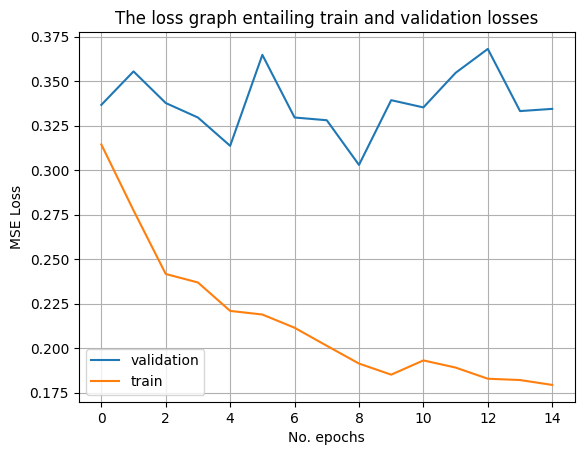

In [22]:
PLT.plot(val_history, label = 'validation')
PLT.plot(train_history, label='train')
PLT.xlabel("No. epochs")
PLT.ylabel("MSE Loss")
PLT.title("The loss graph entailing train and validation losses")
PLT.legend()
PLT.grid()

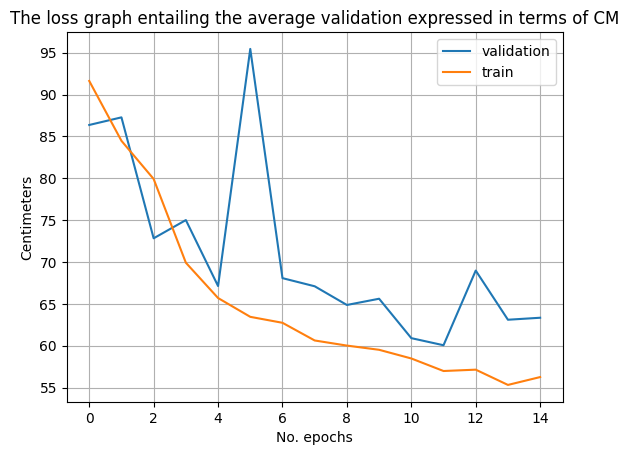

In [32]:
PLT.plot(val_history_cm, label = 'validation')
PLT.plot(train_history_cm, label='train')
PLT.xlabel("No. epochs")
PLT.ylabel("Centimeters")
PLT.title("The loss graph entailing the average validation expressed in terms of CM")
PLT.legend()
PLT.grid()

### 2.3.g)

In [7]:
model = DefaultCNN(4, [4,16,32,64,128], sum=False)
receptive_field = summary(model,(4, 4800), receptive_field=True)

d:\Cristi_s_ground\University\M.L. for signal processing\26-27\.venv\Lib\site-packages\torchscan\modules\flops.py:64: UserWarning: Module type not supported: Flatten
  warnings.warn(f'Module type not supported: {module.__class__.__name__}')
d:\Cristi_s_ground\University\M.L. for signal processing\26-27\.venv\Lib\site-packages\torchscan\modules\macs.py:51: UserWarning: Module type not supported: Flatten
  warnings.warn(f'Module type not supported: {module.__class__.__name__}')
d:\Cristi_s_ground\University\M.L. for signal processing\26-27\.venv\Lib\site-packages\torchscan\modules\memory.py:57: UserWarning: Module type not supported: Flatten
  warnings.warn(f'Module type not supported: {module.__class__.__name__}')
d:\Cristi_s_ground\University\M.L. for signal processing\26-27\.venv\Lib\site-packages\torchscan\modules\receptive.py:46: UserWarning: Module type not supported: Flatten
  warnings.warn(f'Module type not supported: {module.__class__.__name__}')


____________________________________________________________________________________________________________
Layer                        Type                  Output Shape              Param #         Receptive field
defaultcnn                   DefaultCNN            (-1, 2)                   0               592            
├─n                          Sequential            (-1, 2432)                0               592            
|    └─0                     Conv1d                (-1, 16, 1201)            16,400          592            
|    └─1                     BatchNorm1d           (-1, 16, 1201)            65              85             
|    └─2                     LeakyReLU             (-1, 16, 1201)            0               85             
|    └─3                     Conv1d                (-1, 32, 301)             2,592           85             
|    └─4                     BatchNorm1d           (-1, 32, 301)             129             21             
|    └─5           

# Utils (helpers or static methods)

In [5]:
def normalize_targets(coords, mins, maxs):
    """Maps raw cm coordinates to a [-1, 1] range."""
    # Scale to [0, 1] first, then shift to [-1, 1]
    return 2.0 * (coords - mins) / (maxs - mins) - 1.0

def denormalize_predictions(preds, mins, maxs):
    """Maps [-1, 1] model outputs back to raw cm coordinates."""
    # Reverse shift from [-1, 1] to [0, 1], then scale back to cm
    return (preds + 1.0) / 2.0 * (maxs - mins) + mins

In [4]:
@staticmethod
def audio_simulator(input, source_loc:tuple, mic_locs:list|tuple):
    """
    Def:
    :params input
    :params tuple of floats source_loc: Holding the cartesian coordinates of the source; 
    :params list of tuples mic_locs: Holding the cartesian coordinates of multiple microphones. If all the microphones share the same location then the argument becomes a tuple

    Return: waveforms (visualiazation) and time_delays
    """

    def _time_delay_calculation(mic=mic_locs, source=source_loc, common_loc=False):
        for locations in mic:
            relative_time_delays.append(np.round((np.sqrt( (source[0]-locations[0])**2 + (source[1]-locations[1])**2)/c)*sr))

        # 2. Locate the furthest situated microphone by time_delay: the more samples, the furthest
        furtherst = max(relative_time_delays)
        for relative_time in relative_time_delays:
            delay = furtherst-relative_time
            waveforms.append(input[int(delay):])
    
    c:int=340*100
    sr:int = 48000
    relative_time_delays:list = []
    time_delay_of_arival:int = 0
    waveforms:list = []

    if isinstance(mic_locs, tuple):
        _time_delay_calculation(True)
    elif isinstance(mic_locs, list):
        _time_delay_calculation()
    
    
    return waveforms, relative_time_delays

In [3]:
class CustomAudioDecoderData(Dataset):
    """
    :param float t:
    :param list of integers mic_locs:
    :param tuple holding float values n_sources_min_max:
    ....
    """
    def __init__(self, t, mic_locs, n_sources_min, n_sources_max, 
                 x_loc_min, x_loc_max, y_loc_min, y_loc_max, 
                 split='train', epoch_len:int=2560,
                 data_folder=dataset_roots, transforms:bool = None, random_assignment:bool=True, dynamic:bool=True):

        # 1.1 Fail save, ensuring NO-CAPITAL charachters are accidentally inserted;        
        self.split = split.lower()
        # 1.2 Map split string to the correct index of data_folder (0=train, 1=val, 2=test)
        split_mapping = {'train': 0, 'val': 1, 'test': 2}
        if self.split not in split_mapping:
            raise ValueError("split must be 'train', 'val', or 'test'")
        # 1.3 Set a value (e.g., 0, 1 or 2) based on the subset of interest specified at class instantiation time;
        self.split_idx = split_mapping[self.split]

        self.dataset_root_paths = data_folder
        self.transform = transforms
        self.end_time = t/1000 
        self.mic_locs = mic_locs
        self.n_sources = (n_sources_min, n_sources_max)
        self.x_y_min_max = (x_loc_min, x_loc_max, y_loc_min, y_loc_max)
        self.rdm_assign = random_assignment
        self.dynamic = dynamic
        self.epoch_len = epoch_len

        # 1. Collecting data paths
        all_data_paths = self._retrieve_and_assemble_data_paths()

        # 2. Declare active file paths based on step `1.3`
        self.active_paths = all_data_paths[self.split_idx]
    
    def __len__(self):
        return self.epoch_len

    def __getitem__(self, idx):

        # 3.1 Determine how many sources;
        n_sources = rdm.randint(self.n_sources[0], self.n_sources[1])
        # 3.2 Create data holders aka containers;
        all_simulated_waveforms, source_locations = [], []
        # 4. Loop over sources
        for _ in range(n_sources):
            # 4.1 Target a single file path string using the index [1] and a randomly chosen index [rdm]
            file_path = rdm.choice(self.active_paths)
            # 4.2 Assign and save/append the randomly generated coordinates of the sources
            if self.rdm_assign:
                x, y = rdm.uniform(self.x_y_min_max[0], self.x_y_min_max[1]), rdm.uniform(self.x_y_min_max[2], self.x_y_min_max[3])
            else:
                x = self.x_y_min_max[0]
                y = self.x_y_min_max[2]

            source_locations.append((x,y))
            # 4.3 Safely instantiate AudioDecoder with a single string path [1]
            decoder = AudioDecoder(file_path)
            if self.transform:
                # 4.4 Extract audio tensor stream and cut adequately
                waveform = decoder.get_samples_played_in_range(start_seconds=0, stop_seconds=self.end_time) # Length of the returned sample
                #TODO Implement if statement to check for the number of channels
                mono = torch.mean(waveform.data, dim=0) # Averaging the waveform holding at least two channels
                waveforms, delays = audio_simulator(mono, source_loc=(x, y), mic_locs=self.mic_locs) 
                # 4.4.1 Find the samllest length in the list of waveforms
                # ... then use it as a refference for a clamping threshold
                min_length = min([w.shape[0] for w in waveforms])
                # 4.4.2 Trim every waveform to match that minimum length
                trimmed_waveforms = [w[:min_length] for w in waveforms] # Shape waveforms:  [torch.tensor(simmulated waveform) for wave in range(no. mics)]
                # 4.4.3 Stack the trimmed waveforms                     # 
                source_tensor = torch.stack(trimmed_waveforms) # Shape: [n_mics, samples]
                all_simulated_waveforms.append(source_tensor)
                # # Debug statement 2
                # print("Waveform-decoder shape {}\n"
                # "Waveforms-decoder after mono p[ shape {}\n" \
                # "Waveforms after audio simulator and trimming {} plus size of each element {}\n" \
                # "First stacking (torch.stack(trimmed_waveforms)): {}" \
                # "".format(waveform.data.shape, mono.shape, 
                #             len(trimmed_waveforms),(trimmed_waveforms[0].shape, 
                #                                     trimmed_waveforms[1].shape),
                #                                     source_tensor.shape))

        # 5. After the 'for' loop ends a global loop comes into effect,
        # ... whose purpose is to level down all the samples
        if self.dynamic:
            global_min_length = min([w.shape[1] for w in all_simulated_waveforms])
        else:
            global_min_length=4800

        # 5.1 Compute the length of each waveform by using a conditioned list comprehension
        # 5.1.1 IF waveform length higher than global_min_length then chunk off the tail
        all_simulated_and_trimmed_waveforms = [w[:, :global_min_length] if w.shape[1] >= global_min_length 
        # 5.1.2 Else pad zeros starting from left to right
        else torch.nn.functional.pad(w, (0, global_min_length - w.shape[1])) for w in all_simulated_waveforms]
        
        # # Debug statement 3
        # print(all_simulated_waveforms)
        # print(all_simulated_and_trimmed_waveforms)
        # print("Initial len {} vs aftermath len{}".format(len(all_simulated_waveforms), len(all_simulated_and_trimmed_waveforms)))
        
        stacked_tensor = torch.stack(all_simulated_and_trimmed_waveforms) # Shape: [n_sources, n_mics, samples]
        mixed_tensor = torch.sum(stacked_tensor, dim=0)       # Shape: [n_mics, samples]      
        mixed_tensor = mixed_tensor - mixed_tensor.mean(dim=1, keepdim=True)
        scale = mixed_tensor.pow(2).mean().sqrt().clamp_min(1e-8)
        mixed_tensor=mixed_tensor/scale
        
        target_locations = torch.tensor(source_locations).squeeze()
        
        # Informative staement
        # print("Second stacking:",stacked_tensor.shape)
        # print("Third stacking:",mixed_tensor.shape)
        # print("Source tensor shape {} Stacked tensor shape {} Source locations {}".format(source_tensor.shape, stacked_tensor.shape, source_locations))
        
        if self.dynamic:
            return source_tensor, stacked_tensor, source_locations, delays
        else:
             return mixed_tensor, target_locations
  
    def _retrieve_and_assemble_data_paths(self, info:bool=False):
        # 0. Declaring path containers;
        _p_dataset:list = []
        # 1. Determining the number of data sets we're interested in
        # ... commonly stays 3: train, test, val;
        for set in range(len(dataset_roots)):
            # 1.1. Retriveing the .mp3 file names
            names = os.listdir(self.dataset_root_paths[set])
            _p_dataset.append([os.path.join(self.dataset_root_paths[set],item) for item in names])

        if info:
            print(f"Container holding pahts to .mp3 files holds the following content {_p_dataset}")

        return _p_dataset


# Tests

tensor(-8.4244) tensor(11.5851)


(array([8.00000e+00, 8.00000e+00, 0.00000e+00, 1.50000e+01, 1.90000e+01,
        6.00000e+00, 9.00000e+00, 3.80000e+01, 1.90000e+01, 2.80000e+01,
        3.40000e+01, 3.80000e+01, 2.80000e+01, 4.70000e+01, 2.50000e+01,
        9.70000e+01, 1.49000e+02, 8.70000e+01, 7.90000e+01, 1.40000e+02,
        1.59000e+02, 3.22000e+02, 3.04000e+02, 4.36000e+02, 3.96000e+02,
        6.63000e+02, 9.24000e+02, 1.52200e+03, 2.45400e+03, 4.55200e+03,
        6.64700e+03, 9.78300e+03, 1.64840e+04, 1.78390e+04, 2.09400e+04,
        2.48870e+04, 2.80000e+04, 2.91140e+04, 3.44070e+04, 3.96740e+04,
        4.19850e+04, 1.08699e+05, 5.32681e+05, 4.67730e+04, 5.54860e+04,
        3.72220e+04, 3.08150e+04, 2.68780e+04, 2.24840e+04, 1.90270e+04,
        1.73720e+04, 1.45420e+04, 1.22890e+04, 7.25400e+03, 4.96900e+03,
        3.62900e+03, 1.55900e+03, 9.74000e+02, 9.70000e+02, 5.85000e+02,
        4.41000e+02, 2.82000e+02, 2.11000e+02, 2.08000e+02, 1.45000e+02,
        1.29000e+02, 1.45000e+02, 8.90000e+01, 3.60

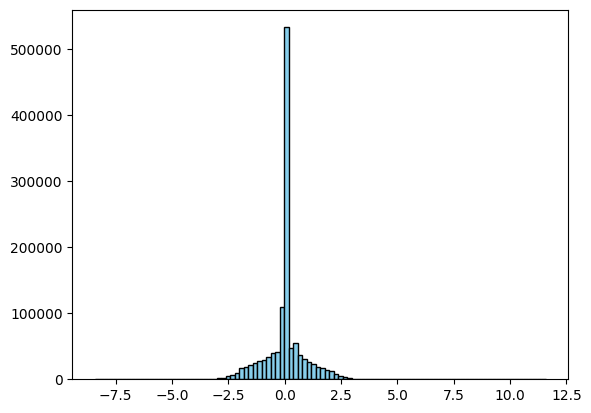

In [31]:
sample=next(enumerate(trainLoader))
_,waveform = sample
data_flattened = waveform[0].flatten()
print(data_flattened.min(), data_flattened.max())
PLT.hist(data_flattened.cpu().numpy(), bins=100, color='skyblue', edgecolor='black')
